# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [2]:
# import pandas
import pandas as pd

In [3]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [5]:
df.head(10), df.tail(10)

(   sepal_length  sepal_width  petal_length  petal_width      species
 0           5.1          3.5           1.4          0.2  Iris-setosa
 1           4.9          3.0           1.4          0.2  Iris-setosa
 2           4.7          3.2           1.3          0.2  Iris-setosa
 3           4.6          3.1           1.5          0.2  Iris-setosa
 4           5.0          3.6           1.4          0.2  Iris-setosa
 5           5.4          3.9           1.7          0.4  Iris-setosa
 6           4.6          3.4           1.4          0.3  Iris-setosa
 7           5.0          3.4           1.5          0.2  Iris-setosa
 8           4.4          2.9           1.4          0.2  Iris-setosa
 9           4.9          3.1           1.5          0.1  Iris-setosa,
      sepal_length  sepal_width  petal_length  petal_width         species
 140           6.7          3.1           5.6          2.4  Iris-virginica
 141           6.9          3.1           5.1          2.3  Iris-virginica
 142

How many irises are in the data set?

In [9]:
df.shape

(150, 5)

In [ ]:
df.info()

# there are 150 irises in this data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


How many different species are there?

In [ ]:
df.species.nunique()

# there are 3 species

3

In [13]:
df.species.value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Calculate the mean, median, mode for petal length

In [14]:
df["petal_length"].describe()

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

In [16]:
df["petal_length"].mean(), df["petal_length"].mode(), df["petal_length"].median() 

(np.float64(3.758666666666666),
 0    1.5
 Name: petal_length, dtype: float64,
 np.float64(4.35))

What can you conclude about the distribution for petal length?

<Axes: ylabel='Frequency'>

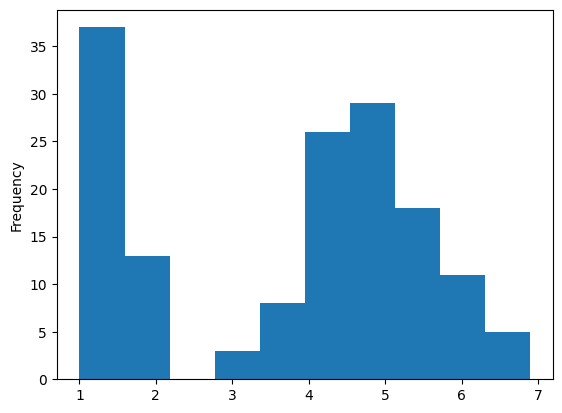

In [17]:
df["petal_length"].plot(kind="hist")

<Axes: >

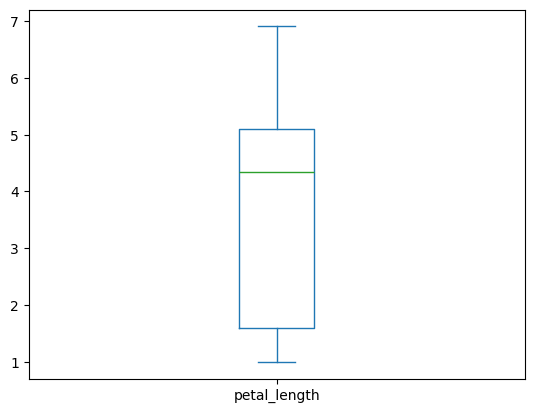

In [ ]:
df["petal_length"].plot(kind="box")

#the data is quite spread, The mode being far from the median = strong asymmetry, The distribution is not normal; it’s multi-modal. maybe because of the 3 species

What is the smallest and largest value for petal length?

In [19]:
df["petal_length"].max(), df["petal_length"].min()

(np.float64(6.9), np.float64(1.0))

Calculate the variance and standard deviation for petal length

In [24]:
variance, standard_deviation = round(df["petal_length"].var(), 2), round(df["petal_length"].std(), 2)

print (f"the variance is: {variance} and the standard deviation is: {standard_deviation}")

the variance is: 3.11 and the standard deviation is: 1.76


Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [25]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [26]:
df["sepal_length"].mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [29]:
df["species"].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [35]:
df.groupby("species").mean()[["sepal_length","sepal_width","petal_length","petal_width"]]

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [37]:
df.groupby("species")[["sepal_length","sepal_width","petal_length","petal_width"]].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


Add the sum of the sepal width and length as a new column to your DataFrame.

In [41]:
df.eval("sepal_sum = sepal_length + sepal_width", inplace=True)

df.columns

df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9


Visualize petal length with a histogram

<Axes: ylabel='Frequency'>

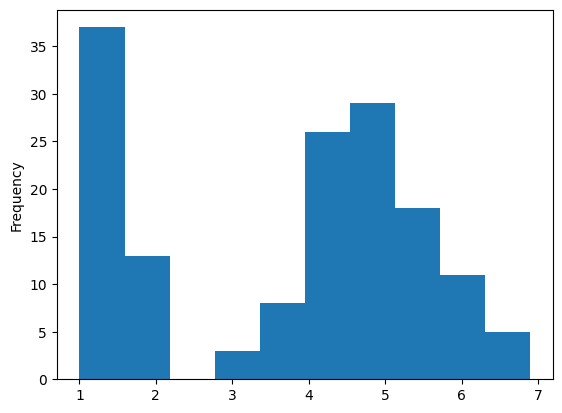

In [42]:
df["petal_length"].plot(kind="hist")

Describe the distribution

In [ ]:
#theres no clear average because there is more that one center

Which is more informative: the summary statistics or visualizations?

In [ ]:
# visualisation

Visualize petal length and width with a "scatter_matrix"

<Axes: xlabel='petal_length', ylabel='petal_width'>

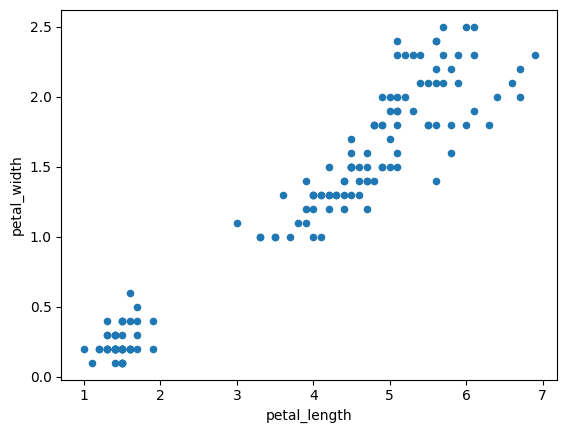

In [45]:
df.plot(kind="scatter", x="petal_length", y="petal_width")

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [46]:
df.eval("petal_area = petal_length * petal_width",inplace=True)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


Create a new DataFrame with petal areas greater than $1cm^2$.

In [49]:
new_df = df.query("petal_area > 1.0")
new_df

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,9.7,11.96
146,6.3,2.5,5.0,1.9,Iris-virginica,8.8,9.50
147,6.5,3.0,5.2,2.0,Iris-virginica,9.5,10.40
148,6.2,3.4,5.4,2.3,Iris-virginica,9.6,12.42


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [53]:
df.species.value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [57]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


In [66]:
grouped = df.groupby("species")

df_Iris_setosa = grouped.get_group("Iris-setosa")
df_Iris_versicolor = grouped.get_group("Iris-versicolor")
df_Iris_virginica = grouped.get_group("Iris-virginica")



#df_Iris_setosa =df.groupby("species")(df.query('species = Iris-setosa'))
df_Iris_setosa


,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28
5,5.4,3.9,1.7,0.4,Iris-setosa,9.3,0.68
6,4.6,3.4,1.4,0.3,Iris-setosa,8.0,0.42
7,5.0,3.4,1.5,0.2,Iris-setosa,8.4,0.30
8,4.4,2.9,1.4,0.2,Iris-setosa,7.3,0.28
9,4.9,3.1,1.5,0.1,Iris-setosa,8.0,0.15


In [67]:
df_Iris_versicolor


,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90
55,5.7,2.8,4.5,1.3,Iris-versicolor,8.5,5.85
56,6.3,3.3,4.7,1.6,Iris-versicolor,9.6,7.52
57,4.9,2.4,3.3,1.0,Iris-versicolor,7.3,3.30
58,6.6,2.9,4.6,1.3,Iris-versicolor,9.5,5.98
59,5.2,2.7,3.9,1.4,Iris-versicolor,7.9,5.46


In [68]:
df_Iris_virginica

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_sum,petal_area
100,6.3,3.3,6.0,2.5,Iris-virginica,9.6,15.00
101,5.8,2.7,5.1,1.9,Iris-virginica,8.5,9.69
102,7.1,3.0,5.9,2.1,Iris-virginica,10.1,12.39
103,6.3,2.9,5.6,1.8,Iris-virginica,9.2,10.08
104,6.5,3.0,5.8,2.2,Iris-virginica,9.5,12.76
105,7.6,3.0,6.6,2.1,Iris-virginica,10.6,13.86
106,4.9,2.5,4.5,1.7,Iris-virginica,7.4,7.65
107,7.3,2.9,6.3,1.8,Iris-virginica,10.2,11.34
108,6.7,2.5,5.8,1.8,Iris-virginica,9.2,10.44
109,7.2,3.6,6.1,2.5,Iris-virginica,10.8,15.25
